In [7]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent.parent.parent
sys.path.insert(0, str(repo_root))

import SysSimX
from SysSimX.utilities.units import ureg
from SysSimX.components.fmu_comp import FMUComponent

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))
from MyModels.FEM.fem_pendulum import FEMPendulum
from MyModels.OpenSim.opensim_pendulum import OpenSimPendulum

In [8]:
# Instantiate the pendulum models
fmu_pendulum_path = Path.cwd() / 'FMUs/Pendulum.fmu'
eqb_pendulum = FMUComponent(name="EQB_Pendulum", fmu_path=fmu_pendulum_path)

fem_pendulum = FEMPendulum(name="FEM_Pendulum")

opensim_pendulum = OpenSimPendulum(name="OpenSim_Pendulum")

In [9]:
# Initialize FEM Pendulum as Master and set EQB and OpenSim Parameters correspondingly
t0 = 0.0
fem_pendulum._use_gravity  = False
fem_pendulum._with_contact = False
fem_pendulum.initialize(t0)

q0 = np.deg2rad(fem_pendulum.init_params.angular_position_deg)
omega0 = fem_pendulum.init_params.angular_velocity

mass = fem_pendulum.mass
inertia = fem_pendulum.inertia
corresponding_length = np.sqrt(inertia / mass)

# Set OpenSim Parameters and initialize
opensim_pendulum.parameters['InitialConditions']['q0'] = q0
opensim_pendulum.parameters['InitialConditions']['omega0'] = omega0
opensim_pendulum.parameters['Model']['mass'] = mass
opensim_pendulum.parameters['Model']['length'] = corresponding_length
opensim_pendulum._use_gravity  = fem_pendulum._use_gravity
opensim_pendulum._with_contact = fem_pendulum._with_contact 
opensim_pendulum.initialize(t0)

# Set EQB Parameters and initialize
eqb_pendulum.parameters['q0'].start = q0
eqb_pendulum.parameters['omega0'].start = omega0
eqb_pendulum.parameters['m'].start = mass
eqb_pendulum.parameters['L'].start = corresponding_length
eqb_pendulum.parameters['g'].start = 0.0 if not fem_pendulum._use_gravity else 9.81
eqb_pendulum.initialize(t0)

print(f"Mass:    {mass:.4f} kg")
print(f"Length:  {corresponding_length:.4f} m")
print(f"inertia: {inertia:.4f} kg m²")


Mass:    121.2496 kg
Length:  0.6732 m
inertia: 54.9510 kg m²
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


In [10]:
fem_pendulum.setup_simulation_diagnostics()

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [11]:
t = 0.0
dt = 0.01
t_end = 1

input_torque = 100 # Nm

t_vals = []
torque_vals = []
alpha_vals = {"EQB": [], "FEM": [], "OpenSim": []}
omega_vals = {"EQB": [], "FEM": [], "OpenSim": []}
q_vals = {"EQB": [], "FEM": [], "OpenSim": []}

while t < t_end:
    if t < 0.25 * t_end or t > 0.75 * t_end:
        torque = input_torque
    else:
        torque = -input_torque
    torque_vals.append(torque)

    # Set input torque for Models
    eqb_pendulum.set_inputs({'torque': torque}, t=t)
    fem_pendulum.set_inputs({'torque': torque}, t=t)
    opensim_pendulum.set_inputs({'torque': torque}, t=t)

    # Do simulation step
    eqb_pendulum.do_step(t, dt)
    fem_pendulum.do_step(t, dt)
    opensim_pendulum.do_step(t, dt)

    # Get outputs
    eqb_res = eqb_pendulum.get_outputs()
    fem_res = fem_pendulum.get_outputs()
    opensim_res = opensim_pendulum.get_outputs()
    
    t += dt
    
    # Store outputs
    t_vals.append(t)
    
    alpha_vals["EQB"].append(eqb_res['alpha'].magnitude)
    omega_vals["EQB"].append(eqb_res['omega'].magnitude)
    q_vals["EQB"].append(eqb_res['q'].magnitude)
    
    alpha_vals["FEM"].append(fem_res['alpha'].magnitude)
    omega_vals["FEM"].append(fem_res['omega'].magnitude)
    q_vals["FEM"].append(fem_res['q'].magnitude)
    
    alpha_vals["OpenSim"].append(opensim_res['alpha'].magnitude)
    omega_vals["OpenSim"].append(opensim_res['omega'].magnitude)
    q_vals["OpenSim"].append(opensim_res['q'].magnitude)

    

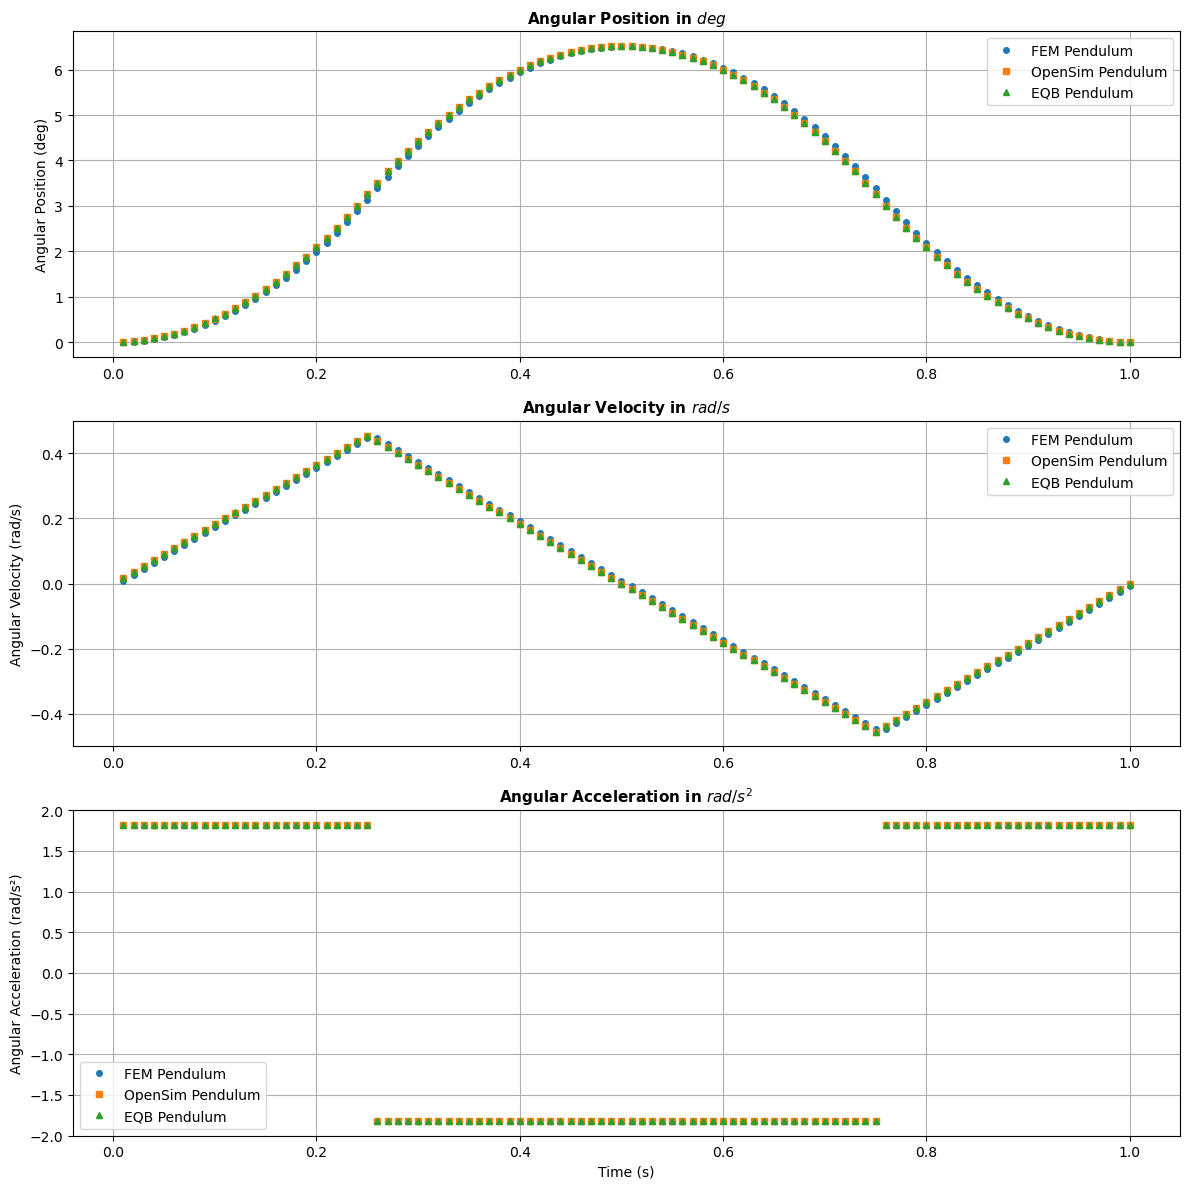

In [12]:
plt.figure(figsize=(12, 12))

marker_size = 4
marker_size = 4
fem_style = {'color': 'C0', 'linestyle': 'None', 'marker': 'o', 'markersize': marker_size}
opensim_style = {'color': 'C1', 'linestyle': 'None', 'marker': 's', 'markersize': marker_size}
eqb_style = {'color': 'C2', 'linestyle': 'None', 'marker': '^', 'markersize': marker_size}
fontdict = {'fontsize': 11, 'fontweight': 'bold'}

plt.subplot(3,1,1).set_title("Angular Position in $deg$", **fontdict)
plt.plot(t_vals, np.rad2deg(q_vals["FEM"]), label="FEM Pendulum", **fem_style)
plt.plot(t_vals, np.rad2deg(q_vals["OpenSim"]), label="OpenSim Pendulum", **opensim_style)
plt.plot(t_vals, np.rad2deg(q_vals["EQB"]), label="EQB Pendulum", **eqb_style)
plt.ylabel("Angular Position (deg)")
plt.legend()
plt.grid(which='both')

plt.subplot(3,1,2).set_title("Angular Velocity in $rad/s$", **fontdict)
plt.plot(t_vals, omega_vals["FEM"], label="FEM Pendulum", **fem_style)
plt.plot(t_vals, omega_vals["OpenSim"], label="OpenSim Pendulum", **opensim_style)
plt.plot(t_vals, omega_vals["EQB"], label="EQB Pendulum", **eqb_style)
plt.ylabel("Angular Velocity (rad/s)")
plt.legend()
plt.grid(which='both')

plt.subplot(3,1,3).set_title("Angular Acceleration in $rad/s^2$", **fontdict)
plt.plot(t_vals, alpha_vals["FEM"], label="FEM Pendulum", **fem_style)
plt.plot(t_vals, alpha_vals["OpenSim"], label="OpenSim Pendulum", **opensim_style)
plt.plot(t_vals, alpha_vals["EQB"], label="EQB Pendulum", **eqb_style)
plt.ylabel("Angular Acceleration (rad/s²)")
plt.grid(which='both')

plt.xlabel("Time (s)")
plt.legend()
plt.tight_layout()
plt.show()